# Convergence of a trained feedback-GRAPE memory

This evaluation-only notebook loads a stored quantum-memory controller and
tests the same ten-step protocol over a grid of cavity cutoffs
$N_{\mathrm{cav}}$ and driven-evolution resolutions `ndt_drive`. Every grid
point uses identical Haar-random input states and identical trajectory random
numbers, so differences are paired rather than dominated by Monte-Carlo noise.

In addition to retrieval fidelity, the sweep records the largest population in
the highest three retained Fock levels and the largest mean photon number seen
during every encoding, feedback, and decoding integration interval. The
largest cutoff and finest time grid are used as the numerical reference.


## GPU allocation and imports

The allocator setting must be applied before importing JAX. Restart the kernel
before running this notebook if JAX was already imported.


In [18]:
import os

# Evaluation is forward-only, but the largest grid points still compile large
# programs. This reserves 95% of HBM as requested.
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

import gc
import json
import time
from datetime import datetime
from pathlib import Path
from zoneinfo import ZoneInfo

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import jax
import jax.numpy as jnp
import jax.scipy as jsp

import optax
import flax.linen as nn
from flax.training.train_state import TrainState
import orbax.checkpoint as ocp

from toolbox import *

print("jax", jax.__version__)
print("jaxlib", jax.lib.__version__)
print("devices", jax.devices())
print(
    "JAX GPU memory fraction:",
    os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"],
)


jax 0.6.2
jaxlib 0.6.2
devices [CudaDevice(id=0)]
JAX GPU memory fraction: 0.95


## User settings

The default below deliberately selects the original pretrained run
`20260720_0935/params_only/1`. Automatic newest-run selection is disabled so a
later continuation cannot silently replace the requested model. Set
`checkpoint_relative_path=None` to select the preferred checkpoint within the
named run, or set `explicit_checkpoint_path` to bypass run-based selection.

The default sweep contains 16 independently compiled simulations. Start with
the defaults; extend the largest cutoff or finest time grid only if the final
rows or columns have not converged.


In [19]:
# Checkpoint selection.
quantum_memory_root = Path("quantum_memory").resolve()
trained_run_name = "20260720_0935"
checkpoint_relative_path = Path("params_only") / "1"
explicit_checkpoint_path = None
allow_automatic_newest_run = False

# Protocol being tested.
num_feedback_steps_test = 10

# Numerical convergence grid.
N_cav_values = [20,30,50,70]
ndt_drive_values = [150,210,280]

# Identical random samples are used at every grid point.
evaluation_seed = 20260721
evaluation_microbatch_size = 16
evaluation_num_microbatches = 4
evaluation_sample_count = (
    evaluation_microbatch_size * evaluation_num_microbatches
)

# Suggested numerical acceptance criteria relative to the largest grid point.
mean_fidelity_tolerance = 1.0e-3
rms_fidelity_tolerance = 3.0e-3
edge_population_tolerance = 1.0e-5

# Pulse/controller architecture must match the stored checkpoint.
num_bspln = 20
delta_ns = 64
t_idle = 10.0
edge_fock_levels = 3

print("Number of paired validation trajectories:", evaluation_sample_count)
print("Grid points:", len(N_cav_values) * len(ndt_drive_values))


Number of paired validation trajectories: 64
Grid points: 12


## Experimental parameters and controller architecture

The Hamiltonians, dissipation channels, B-spline convention, recurrent
controller, encoder, decoder, and trainable shared initial carry match the
training notebook. The optimizer below is only a placeholder required by
`TrainState`; no optimization is performed.


In [20]:
def _strip_comment_keys(obj):
    if isinstance(obj, dict):
        return {
            key: _strip_comment_keys(value)
            for key, value in obj.items()
            if not (isinstance(key, str) and key.startswith("//"))
        }
    if isinstance(obj, list):
        return [_strip_comment_keys(value) for value in obj]
    return obj


def load_config_dict(
    config_directory: Path,
    filename: str = "configuration.json",
):
    path = (config_directory / filename).resolve()
    with path.open("r", encoding="utf-8") as file:
        return _strip_comment_keys(json.load(file))


cfg = load_config_dict(Path(""))

chi = -2 * jnp.pi * cfg["chi_kHz"] * 1e-3
K_cg = 2 * jnp.pi * cfg["self_Kerr_kHz"] * 1e-3
K_ce = 2 * jnp.pi * cfg["self_Kerr_if_qubit_in_e_kHz"] * 1e-3
t1_qub = cfg["qubit_T1_us"]
t2_qub = cfg["qubit_T2_us"]
t1_cav = cfg["storage_T1_us"]

k = 2
skip_left = k
skip_right = k
n_knots = num_bspln + skip_left + skip_right
n_intervals = n_knots - k
T_ns_hw = n_intervals * delta_ns
t_drive = T_ns_hw / 1000.0
L_ns = (k + 1) * delta_ns

inp_shape = (1,)
rec_features = 4 * num_bspln
dense_features = [2 * rec_features, 2 * rec_features]
pulse_init_scale = 0.04


class FeedbackPolicy(nn.Module):
    @nn.compact
    def __call__(self, carry, x):
        gru_cell = nn.GRUCell(features=rec_features)
        carry, x = gru_cell(carry, x)
        for n_features in dense_features:
            x = nn.Dense(n_features)(x)
            x = jax.nn.relu(x)
        x = nn.Dense(4 * num_bspln)(x)
        return carry, x.reshape(4, num_bspln)


def init_carry(key):
    return nn.GRUCell(features=rec_features).initialize_carry(
        key, inp_shape
    )


def create_evaluation_state(key):
    key_model, key_enc, key_dec = jax.random.split(key, 3)
    model = FeedbackPolicy()
    fake_carry = init_carry(jax.random.key(0))
    fake_input = jnp.ones(inp_shape)
    controller_params = model.init(
        key_model, fake_carry, fake_input
    )["params"]
    params = {
        "controller": controller_params,
        "initial_carry": jnp.zeros_like(fake_carry),
        "encoding_coeffs": pulse_init_scale * jax.random.normal(
            key_enc, (4, num_bspln)
        ),
        "decoding_coeffs": pulse_init_scale * jax.random.normal(
            key_dec, (4, num_bspln)
        ),
    }
    return TrainState.create(
        apply_fn=model.apply,
        params=params,
        tx=optax.adam(1.0e-6),
    )


def apply_feedback_policy(train_state, params, carry, measurement):
    return train_state.apply_fn(
        {"params": params["controller"]}, carry, measurement
    )


train_state = create_evaluation_state(jax.random.key(1234))

print("chi / 2pi (MHz):", float(chi / (2 * jnp.pi)))
print("pulse duration (us):", t_drive)
print("controller carry size:", rec_features)


chi / 2pi (MHz): -0.6597474879999999
pulse duration (us): 1.408
controller carry size: 80


## Locate and load the stored parameters

The requested run and relative checkpoint are resolved first. If
`checkpoint_relative_path=None`, selection within the named run prefers
`params_final`, then the newest completed `params_by_stage`, and finally
`params_only`. Selection across different runs occurs only when
`allow_automatic_newest_run=True`. Legacy checkpoints without a trained initial
carry are supported by inserting the same zero carry used during their original
training.


In [21]:
checkpointer = ocp.Checkpointer(
    ocp.StandardCheckpointHandler()
)


def checkpoints_in_run(run_folder):
    candidates_by_preference = []
    for subdirectory in (
        "params_final",
        "params_by_stage",
        "params_only",
    ):
        root = run_folder / subdirectory
        candidates = (
            sorted(
                path for path in root.iterdir() if path.is_dir()
            )
            if root.exists()
            else []
        )
        if candidates:
            candidates_by_preference.extend(reversed(candidates))
            # A preferred checkpoint class was found; do not fall through
            # to older, less complete checkpoint classes.
            break
    return candidates_by_preference


if explicit_checkpoint_path is not None:
    selected_checkpoint_path = Path(
        explicit_checkpoint_path
    ).resolve()
    if quantum_memory_root in selected_checkpoint_path.parents:
        relative_checkpoint = selected_checkpoint_path.relative_to(
            quantum_memory_root
        )
        selected_run_folder = (
            quantum_memory_root / relative_checkpoint.parts[0]
        )
    else:
        selected_run_folder = selected_checkpoint_path.parent
else:
    if trained_run_name is not None:
        selected_run_folder = quantum_memory_root / trained_run_name
        if checkpoint_relative_path is not None:
            selected_checkpoint_path = (
                selected_run_folder / checkpoint_relative_path
            )
        else:
            candidates = checkpoints_in_run(selected_run_folder)
            if not candidates:
                raise FileNotFoundError(
                    "No parameter checkpoint found in "
                    f"{selected_run_folder}"
                )
            selected_checkpoint_path = candidates[0]
    else:
        if not allow_automatic_newest_run:
            raise ValueError(
                "Set trained_run_name or explicit_checkpoint_path. "
                "Automatic newest-run selection is disabled."
            )
        selected_run_folder = None
        selected_checkpoint_path = None
        if not quantum_memory_root.exists():
            raise FileNotFoundError(quantum_memory_root)
        for possible_run in sorted(
            (
                path
                for path in quantum_memory_root.iterdir()
                if path.is_dir()
            ),
            reverse=True,
        ):
            candidates = checkpoints_in_run(possible_run)
            if candidates:
                selected_run_folder = possible_run
                selected_checkpoint_path = candidates[0]
                break
        if selected_checkpoint_path is None:
            raise FileNotFoundError(
                f"No parameter checkpoint found under {quantum_memory_root}"
            )

if not selected_checkpoint_path.exists():
    available = checkpoints_in_run(selected_run_folder)
    available_text = "\n".join(
        f"  {path}" for path in available
    )
    raise FileNotFoundError(
        f"Requested checkpoint does not exist:\n"
        f"  {selected_checkpoint_path}\n"
        f"Available preferred checkpoints in this run:\n"
        f"{available_text or '  none'}"
    )

if (
    trained_run_name is not None
    and explicit_checkpoint_path is None
    and selected_run_folder.name != trained_run_name
):
    raise RuntimeError(
        "Checkpoint run mismatch: requested "
        f"{trained_run_name}, selected {selected_run_folder.name}."
    )


def without_initial_carry(params):
    legacy_params = dict(params)
    legacy_params.pop("initial_carry", None)
    return legacy_params


def with_zero_initial_carry(params):
    if "initial_carry" in params:
        return params
    params_with_carry = dict(params)
    params_with_carry["initial_carry"] = jnp.zeros_like(
        train_state.params["initial_carry"]
    )
    return params_with_carry


def restore_parameters_with_optional_carry(checkpoint_path):
    try:
        restored = checkpointer.restore(
            checkpoint_path,
            args=ocp.args.StandardRestore(train_state.params),
        )
        return with_zero_initial_carry(restored), (
            "initial_carry" not in restored
        )
    except Exception as carry_restore_error:
        legacy_target = without_initial_carry(train_state.params)
        try:
            restored = checkpointer.restore(
                checkpoint_path,
                args=ocp.args.StandardRestore(legacy_target),
            )
        except Exception:
            raise carry_restore_error
        return with_zero_initial_carry(restored), True


restored_params, inserted_zero_carry = (
    restore_parameters_with_optional_carry(
        selected_checkpoint_path
    )
)
train_state = train_state.replace(
    step=0,
    params=restored_params,
    opt_state=train_state.tx.init(restored_params),
)

print("Selected run:", selected_run_folder)
print("Loaded parameters from:", selected_checkpoint_path)
print(
    "Requested run matched:",
    selected_run_folder.name == trained_run_name,
)
print("Loaded initial carry norm:", float(
    optax.global_norm(restored_params["initial_carry"])
))
if inserted_zero_carry:
    print("Legacy checkpoint: inserted a zero initial carry.")


Selected run: /home/user/python_experiments/train_feedback_grape/quantum_memory/20260720_0935
Loaded parameters from: /home/user/python_experiments/train_feedback_grape/quantum_memory/20260720_0935/params_only/1
Requested run matched: True
Loaded initial carry norm: 0.0
Legacy checkpoint: inserted a zero initial carry.


## Physical model with parameterized numerical resolution

These are the same Hamiltonian and Lindblad equations used during training.
The driven time grid is passed explicitly into the trajectory constructors so
several `ndt_drive` values can coexist in one kernel without redefining global
variables.

Photon diagnostics are accumulated inside the driven `lax.scan`; only their
running maxima are retained, so the complete density-matrix trajectory is not
stored.


In [22]:
def liouv_relax_channel(c):
    d = c.shape[0]
    I = identity(d)
    cdag_c = hconj(c) @ c
    L = tensor(c, c.conj())
    L -= 0.5 * tensor(cdag_c, I)
    L -= 0.5 * tensor(I, cdag_c.T)
    return L


def liouv_hamiltonian(H):
    d = H.shape[0]
    I = identity(d)
    return -1j * (tensor(H, I) - tensor(I, H.T))


def make_cavity_idle_matrix(N_cav, t1_cav, t_idle):
    a = destroy(N_cav)
    adag = hconj(a)
    H_kerr_cav = 0.5 * K_cg * adag @ adag @ a @ a
    c_loss = a / jnp.sqrt(t1_cav)
    L_idle = liouv_hamiltonian(H_kerr_cav)
    L_idle += liouv_relax_channel(c_loss)
    return jsp.linalg.expm(L_idle * t_idle)


def make_idle_cav(N_cav, t1_cav, t_idle):
    idle_cav_matrix = make_cavity_idle_matrix(
        N_cav, t1_cav, t_idle
    )
    ket_g = basis(2)
    rho_g = ket_g @ hconj(ket_g)

    def idle_cav(rho):
        rho_cav = rho[:N_cav, :N_cav]
        rho_cav = (
            idle_cav_matrix @ rho_cav.reshape(-1, 1)
        ).reshape(N_cav, N_cav)
        rho_out = tensor(rho_g, rho_cav)
        return rho_out / jnp.trace(rho_out)

    return idle_cav


mu_qub = 20.0
mu_cav = 20.0


def build_drive_htree(N_cav, chi, e_qub, e_cav):
    a = tensor(identity(2), destroy(N_cav))
    adag = hconj(a)
    n_phot = adag @ a
    sigz = tensor(sigma.z, identity(N_cav))
    sigp = tensor(sigma.p, identity(N_cav))
    one = tensor(identity(2), identity(N_cav))
    H_disp = (chi / 2) * n_phot @ (one - sigz)
    proj_g = 0.5 * (one + sigz)
    proj_e = 0.5 * (one - sigz)
    kerr_op = adag @ adag @ a @ a
    H_kerr = (
        0.5 * (K_cg * proj_g + K_ce * proj_e) @ kerr_op
    )
    H_drift = H_disp + H_kerr
    return [
        [H_drift, 1, 1, 0],
        [mu_qub * sigp, e_qub, 1, 1],
        [mu_cav * adag, 1j * jnp.conj(e_cav), 1, 1],
    ]


def get_uevol_matrix(N_cav, chi, e_qub, e_cav, dt):
    htree = build_drive_htree(N_cav, chi, e_qub, e_cav)
    return evol_hdt_exp(hmat_from_htree(htree), dt)


def liouv_relax_channel_qubit_cav(c):
    L = tensor(c, c.conj())
    L -= 0.5 * tensor(hconj(c) @ c, identity(len(c)))
    L -= 0.5 * tensor(identity(len(c)), (hconj(c) @ c).T)
    return L


def eval_idling_matrix(c_ops, t):
    L = sum(liouv_relax_channel_qubit_cav(c) for c in c_ops)
    return jsp.linalg.expm(L * t)


def build_c_ops(N_cav, t1_qub, t2_qub, t1_cav):
    t_phi_qub = 1 / ((1 / t2_qub) - (1 / t1_qub) / 2)
    sigm = tensor(sigma.m, identity(N_cav))
    sigz = tensor(sigma.z, identity(N_cav))
    a = tensor(identity(2), destroy(N_cav))
    return [
        sigm / jnp.sqrt(t1_qub),
        sigz / jnp.sqrt(2 * t_phi_qub),
        a / jnp.sqrt(t1_cav),
    ]


def make_idle_dt(N_cav, t1_qub, t2_qub, t1_cav, t):
    idling_matrix = eval_idling_matrix(
        build_c_ops(N_cav, t1_qub, t2_qub, t1_cav), t
    )

    def idle_dt(rho):
        rho_vec = idling_matrix @ rho.reshape(-1, 1)
        return rho_vec.reshape(rho.shape)

    return idle_dt


def cavity_edge_and_mean_photon(rho, N_cav):
    rho_tensor = rho.reshape(2, N_cav, 2, N_cav)
    rho_cav = jnp.trace(rho_tensor, axis1=0, axis2=2)
    populations = jnp.real(jnp.diag(rho_cav))
    number = jnp.arange(N_cav, dtype=populations.dtype)
    edge_population = jnp.sum(populations[-edge_fock_levels:])
    mean_photon = jnp.sum(number * populations)
    return edge_population, mean_photon


def make_drive_with_relax(
    N_cav,
    chi,
    t1_qub,
    t2_qub,
    t1_cav,
    dt_idle,
):
    idle_after_drive_dt = make_idle_dt(
        N_cav, t1_qub, t2_qub, t1_cav, dt_idle
    )

    def drive_with_relax(rho_init, es_qub, es_cav, dts):
        edge_initial, photon_initial = cavity_edge_and_mean_photon(
            rho_init, N_cav
        )

        def one_interval(carry, fields_and_dt):
            rho, max_edge, max_photon = carry
            e_qub, e_cav, dt = fields_and_dt
            U = get_uevol_matrix(
                N_cav, chi, e_qub, e_cav, dt
            )[0]
            rho = U @ rho @ hconj(U)
            rho = idle_after_drive_dt(rho)
            edge, photon = cavity_edge_and_mean_photon(
                rho, N_cav
            )
            return (
                rho,
                jnp.maximum(max_edge, edge),
                jnp.maximum(max_photon, photon),
            ), None

        (rho_final, max_edge, max_photon), _ = jax.lax.scan(
            one_interval,
            (rho_init, edge_initial, photon_initial),
            [es_qub, es_cav, dts],
        )
        return rho_final, max_edge, max_photon

    return drive_with_relax


def ctrl_from_coeffs(ctrl_coeffs, bsplines):
    controls = ctrl_coeffs @ bsplines
    e_qub = controls[0] + 1j * controls[1]
    e_cav = controls[2] + 1j * controls[3]
    return e_qub, e_cav


def measure_sz(key, rho_init):
    probs = rho_init.diagonal().reshape(2, -1).sum(axis=1).real
    outcome_index = jax.random.choice(key, 2, p=probs)
    prob = probs[outcome_index]
    half_dimension = rho_init.shape[0] // 2
    rho_cav = jnp.where(
        outcome_index == 0,
        rho_init[:half_dimension, :half_dimension],
        rho_init[half_dimension:, half_dimension:],
    )
    ket_g = basis(2)
    rho_out = tensor(ket_g @ hconj(ket_g), rho_cav)
    rho_out /= jnp.trace(rho_out)
    measurement = 1 - 2 * outcome_index
    return measurement, prob, rho_out


def sample_haar_qubit(key):
    key_z, key_phi = jax.random.split(key)
    z = jax.random.uniform(key_z, minval=-1.0, maxval=1.0)
    phi = 2 * jnp.pi * jax.random.uniform(key_phi)
    alpha = jnp.sqrt((1.0 + z) / 2.0)
    beta = jnp.exp(1j * phi) * jnp.sqrt((1.0 - z) / 2.0)
    psi = alpha * basis(2, 0) + beta * basis(2, 1)
    return psi


def reduced_qubit_state(rho_joint, N_cav):
    rho_tensor = rho_joint.reshape(2, N_cav, 2, N_cav)
    return jnp.trace(rho_tensor, axis1=1, axis2=3)


def qubit_state_fidelity(rho_qubit, psi_target):
    return jnp.real(
        (hconj(psi_target) @ rho_qubit @ psi_target)[0, 0]
    )


def build_drive_grid(ndt_drive):
    edges = jnp.linspace(0.0, t_drive, ndt_drive + 1)
    mids = 0.5 * (edges[1:] + edges[:-1])
    intervals = edges[1:] - edges[:-1]
    bspline_builder = setup_bspline_builder(
        0.0,
        edges[-1],
        n_knots,
        k,
        skip_left,
        skip_right,
    )
    return {
        "intervals": intervals,
        "bsplines_mids": bspline_builder(mids),
    }


In [23]:
def make_feedback_step(
    N_cav,
    chi,
    t1_qub,
    t2_qub,
    t1_cav,
    t_idle,
    drive_grid,
):
    idle_cav = make_idle_cav(N_cav, t1_cav, t_idle)
    drive = make_drive_with_relax(
        N_cav,
        chi,
        t1_qub,
        t2_qub,
        t1_cav,
        drive_grid["intervals"][0],
    )

    def feedback_step(key, rho, train_state, params, carry):
        measurement, prob, rho = measure_sz(key, rho)
        rho = idle_cav(rho)
        rnn_input = jnp.array([measurement], dtype=float)
        carry, ctrl_coeffs = apply_feedback_policy(
            train_state, params, carry, rnn_input
        )
        e_qub, e_cav = ctrl_from_coeffs(
            ctrl_coeffs, drive_grid["bsplines_mids"]
        )
        rho, max_edge, max_photon = drive(
            rho, e_qub, e_cav, drive_grid["intervals"]
        )
        return (
            rho,
            carry,
            measurement,
            prob,
            max_edge,
            max_photon,
        )

    return feedback_step


def make_random_trajectory(
    N_cav,
    chi,
    t1_qub,
    t2_qub,
    t1_cav,
    t_idle,
    drive_grid,
    num_feedback_steps,
):
    feedback_step = make_feedback_step(
        N_cav,
        chi,
        t1_qub,
        t2_qub,
        t1_cav,
        t_idle,
        drive_grid,
    )
    drive = make_drive_with_relax(
        N_cav,
        chi,
        t1_qub,
        t2_qub,
        t1_cav,
        drive_grid["intervals"][0],
    )

    def random_trajectory(key, train_state):
        key_input, key_dynamics = jax.random.split(key)
        psi_input = sample_haar_qubit(key_input)
        _, key_scan = jax.random.split(key_dynamics)
        params = train_state.params
        carry = params["initial_carry"]

        psi_initial = tensor(psi_input, basis(N_cav, 0))
        rho = psi_initial @ hconj(psi_initial)

        e_qub, e_cav = ctrl_from_coeffs(
            params["encoding_coeffs"],
            drive_grid["bsplines_mids"],
        )
        rho, encoding_edge, encoding_photon = drive(
            rho, e_qub, e_cav, drive_grid["intervals"]
        )

        def one_feedback_step(scan_carry, _):
            key_step, rho_step, carry_step = scan_carry
            key_step, subkey = jax.random.split(key_step)
            (
                rho_step,
                carry_step,
                measurement,
                prob,
                max_edge,
                max_photon,
            ) = feedback_step(
                subkey,
                rho_step,
                train_state,
                params,
                carry_step,
            )
            return (
                key_step,
                rho_step,
                carry_step,
            ), (
                measurement,
                prob,
                max_edge,
                max_photon,
            )

        (
            (_, rho, carry),
            (_, _, feedback_edges, feedback_photons),
        ) = jax.lax.scan(
            one_feedback_step,
            (key_scan, rho, carry),
            length=num_feedback_steps,
        )

        e_qub, e_cav = ctrl_from_coeffs(
            params["decoding_coeffs"],
            drive_grid["bsplines_mids"],
        )
        rho, decoding_edge, decoding_photon = drive(
            rho, e_qub, e_cav, drive_grid["intervals"]
        )

        rho_qubit_out = reduced_qubit_state(rho, N_cav)
        fidelity = qubit_state_fidelity(
            rho_qubit_out, psi_input
        )
        max_edge = jnp.maximum(
            jnp.maximum(encoding_edge, decoding_edge),
            jnp.max(feedback_edges),
        )
        max_photon = jnp.maximum(
            jnp.maximum(encoding_photon, decoding_photon),
            jnp.max(feedback_photons),
        )
        return fidelity, max_edge, max_photon

    return random_trajectory


def make_evaluation_batch(
    N_cav,
    ndt_drive,
    microbatch_size,
    num_feedback_steps,
):
    drive_grid = build_drive_grid(ndt_drive)
    random_trajectory = make_random_trajectory(
        N_cav,
        chi,
        t1_qub,
        t2_qub,
        t1_cav,
        t_idle,
        drive_grid,
        num_feedback_steps,
    )
    batched_trajectory = jax.vmap(
        random_trajectory, in_axes=(0, None)
    )

    @jax.jit
    def evaluate_batch(key, train_state):
        keys = jax.random.split(key, microbatch_size)
        return batched_trajectory(keys, train_state)

    return evaluate_batch


## Run the paired convergence sweep

The first microbatch time includes JAX compilation and GPU autotuning. Later
microbatches measure execution. Results are checkpointed after every grid
point. Compiled executables are cleared between points because they will not be
reused and otherwise consume substantial memory during a large sweep.


In [24]:
timestamp = datetime.now(ZoneInfo("Europe/Paris")).strftime(
    "%Y%m%d_%H%M%S"
)
results_folder = (
    selected_run_folder / "convergence_tests" / timestamp
)
results_folder.mkdir(parents=True, exist_ok=False)
partial_results_path = results_folder / "convergence_results.npz"

N_cav_values_array = np.asarray(N_cav_values, dtype=int)
ndt_drive_values_array = np.asarray(ndt_drive_values, dtype=int)
grid_shape = (len(N_cav_values), len(ndt_drive_values))
sample_shape = grid_shape + (evaluation_sample_count,)

fidelity_samples = np.full(sample_shape, np.nan)
edge_population_samples = np.full(sample_shape, np.nan)
max_photon_samples = np.full(sample_shape, np.nan)
compile_first_batch_seconds = np.full(grid_shape, np.nan)
remaining_evaluation_seconds = np.full(grid_shape, np.nan)

evaluation_keys = jax.random.split(
    jax.random.key(evaluation_seed),
    evaluation_num_microbatches,
)


def save_partial_results():
    np.savez(
        partial_results_path,
        N_cav_values=N_cav_values_array,
        ndt_drive_values=ndt_drive_values_array,
        num_feedback_steps_test=np.asarray(num_feedback_steps_test),
        evaluation_seed=np.asarray(evaluation_seed),
        evaluation_microbatch_size=np.asarray(
            evaluation_microbatch_size
        ),
        evaluation_num_microbatches=np.asarray(
            evaluation_num_microbatches
        ),
        fidelity_samples=fidelity_samples,
        edge_population_samples=edge_population_samples,
        max_photon_samples=max_photon_samples,
        compile_first_batch_seconds=compile_first_batch_seconds,
        remaining_evaluation_seconds=remaining_evaluation_seconds,
    )


grid_points = [
    (N_index, dt_index, N_cav_value, ndt_value)
    for N_index, N_cav_value in enumerate(N_cav_values)
    for dt_index, ndt_value in enumerate(ndt_drive_values)
]

progress = tqdm(grid_points, desc="convergence grid", dynamic_ncols=True)
for N_index, dt_index, N_cav_value, ndt_value in progress:
    progress.set_postfix(N_cav=N_cav_value, ndt=ndt_value)
    evaluate_batch = make_evaluation_batch(
        N_cav_value,
        ndt_value,
        evaluation_microbatch_size,
        num_feedback_steps_test,
    )

    fidelity_batches = []
    edge_batches = []
    photon_batches = []

    start = time.perf_counter()
    first_output = evaluate_batch(evaluation_keys[0], train_state)
    first_output = jax.tree.map(jax.device_get, first_output)
    compile_first_batch_seconds[N_index, dt_index] = (
        time.perf_counter() - start
    )
    fidelity_batches.append(np.asarray(first_output[0]))
    edge_batches.append(np.asarray(first_output[1]))
    photon_batches.append(np.asarray(first_output[2]))

    start = time.perf_counter()
    for microbatch_key in evaluation_keys[1:]:
        output = evaluate_batch(microbatch_key, train_state)
        output = jax.tree.map(jax.device_get, output)
        fidelity_batches.append(np.asarray(output[0]))
        edge_batches.append(np.asarray(output[1]))
        photon_batches.append(np.asarray(output[2]))
    remaining_evaluation_seconds[N_index, dt_index] = (
        time.perf_counter() - start
    )

    fidelity_samples[N_index, dt_index] = np.concatenate(
        fidelity_batches
    )
    edge_population_samples[N_index, dt_index] = np.concatenate(
        edge_batches
    )
    max_photon_samples[N_index, dt_index] = np.concatenate(
        photon_batches
    )
    save_partial_results()

    del evaluate_batch, first_output
    if "output" in locals():
        del output
    jax.clear_caches()
    gc.collect()

print("Saved paired sweep to:", partial_results_path)


convergence grid:  75%|███████▌  | 9/12 [02:39<01:13, 24.57s/it, N_cav=70, ndt=150]/home/user/dgx-suite/applications/server/.venv/lib/python3.10/site-packages/jax/_src/interpreters/mlir.py:1135: UserWarning: A large amount of constants were captured during lowering (6.34GB total). If this is intentional, disable this warning by setting JAX_CAPTURED_CONSTANTS_WARN_BYTES=-1. To obtain a report of where these constants were encountered, set JAX_CAPTURED_CONSTANTS_REPORT_FRAMES=-1.
  warnings.warn(message)
convergence grid: 100%|██████████| 12/12 [06:39<00:00, 33.29s/it, N_cav=70, ndt=280]

Saved paired sweep to: /home/user/python_experiments/train_feedback_grape/quantum_memory/20260720_0935/convergence_tests/20260721_141129/convergence_results.npz


## Paired convergence analysis

The reference is the bottom-right grid point: the largest cavity cutoff and
largest `ndt_drive`. `mean ΔF` can hide cancellation, so the RMS and maximum
absolute per-trajectory differences are shown as well. A trustworthy cutoff
also needs negligible population near its upper Fock boundary.


In [25]:
reference_fidelities = fidelity_samples[-1, -1]

mean_fidelity = np.nanmean(fidelity_samples, axis=-1)
fidelity_sem = np.nanstd(
    fidelity_samples, axis=-1, ddof=1
) / np.sqrt(evaluation_sample_count)

paired_difference_samples = (
    fidelity_samples - reference_fidelities[None, None, :]
)
paired_mean_difference = np.nanmean(
    paired_difference_samples, axis=-1
)
paired_difference_sem = np.nanstd(
    paired_difference_samples, axis=-1, ddof=1
) / np.sqrt(evaluation_sample_count)
paired_rms_difference = np.sqrt(
    np.nanmean(paired_difference_samples ** 2, axis=-1)
)
paired_max_abs_difference = np.nanmax(
    np.abs(paired_difference_samples), axis=-1
)

worst_edge_population = np.nanmax(
    edge_population_samples, axis=-1
)
worst_mean_photon = np.nanmax(max_photon_samples, axis=-1)
total_seconds = (
    compile_first_batch_seconds + remaining_evaluation_seconds
)

print(
    "Reference: "
    f"N_cav={N_cav_values[-1]}, ndt_drive={ndt_drive_values[-1]}, "
    f"F={mean_fidelity[-1, -1]:.8f} +/- "
    f"{fidelity_sem[-1, -1]:.2e}\n"
)
print(
    " N_cav  ndt       fidelity +/- SEM      "
    "mean dF +/- paired SEM    RMS dF     edge max   max <n>   sec"
)
for N_index, N_cav_value in enumerate(N_cav_values):
    for dt_index, ndt_value in enumerate(ndt_drive_values):
        print(
            f" {N_cav_value:5d}  {ndt_value:3d}  "
            f"{mean_fidelity[N_index, dt_index]:.8f} +/- "
            f"{fidelity_sem[N_index, dt_index]:.1e}   "
            f"{paired_mean_difference[N_index, dt_index]:+9.2e} +/- "
            f"{paired_difference_sem[N_index, dt_index]:.1e}   "
            f"{paired_rms_difference[N_index, dt_index]:.2e}   "
            f"{worst_edge_population[N_index, dt_index]:.2e}   "
            f"{worst_mean_photon[N_index, dt_index]:6.2f}  "
            f"{total_seconds[N_index, dt_index]:7.1f}"
        )

converged = (
    (np.abs(paired_mean_difference) <= mean_fidelity_tolerance)
    & (paired_rms_difference <= rms_fidelity_tolerance)
    & (worst_edge_population <= edge_population_tolerance)
)

print("\nGrid points satisfying all configured criteria:")
for N_index, dt_index in np.argwhere(converged):
    print(
        f"  N_cav={N_cav_values[N_index]}, "
        f"ndt_drive={ndt_drive_values[dt_index]}"
    )


Reference: N_cav=70, ndt_drive=280, F=0.78666540 +/- 2.15e-02

 N_cav  ndt       fidelity +/- SEM      mean dF +/- paired SEM    RMS dF     edge max   max <n>   sec
    20  150  0.69209493 +/- 1.8e-02   -9.46e-02 +/- 1.3e-02   1.38e-01   4.22e-01    13.57      6.3
    20  210  0.78478599 +/- 1.9e-02   -1.88e-03 +/- 6.2e-03   4.95e-02   3.50e-01    12.94      7.7
    20  280  0.79599449 +/- 2.0e-02   +9.33e-03 +/- 6.0e-03   4.83e-02   3.60e-01    12.79      9.1
    30  150  0.68840364 +/- 1.9e-02   -9.83e-02 +/- 1.2e-02   1.38e-01   3.07e-01    20.75      9.0
    30  210  0.78023042 +/- 2.1e-02   -6.43e-03 +/- 5.3e-03   4.27e-02   3.13e-01    20.87     10.5
    30  280  0.78609446 +/- 2.2e-02   -5.71e-04 +/- 6.8e-04   5.41e-03   3.06e-01    21.07     12.3
    50  150  0.68899860 +/- 1.9e-02   -9.77e-02 +/- 1.2e-02   1.38e-01   7.38e-02    25.21     21.8
    50  210  0.77602335 +/- 2.1e-02   -1.06e-02 +/- 1.8e-03   1.78e-02   6.79e-02    25.07     24.8
    50  280  0.78339599 +/- 2.1e-02

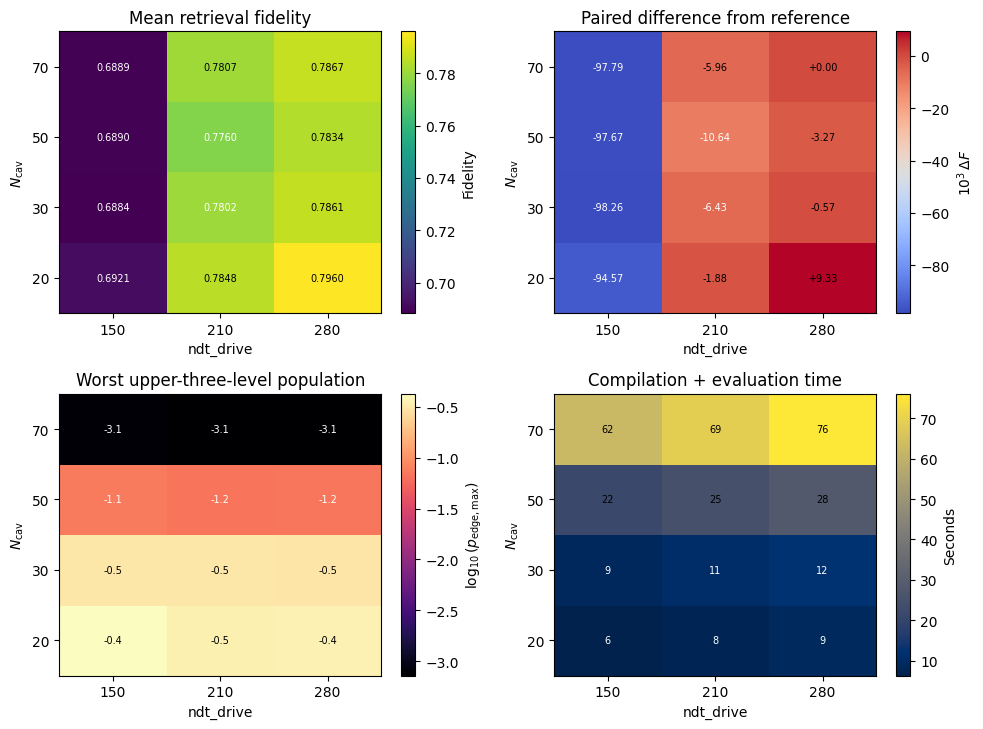

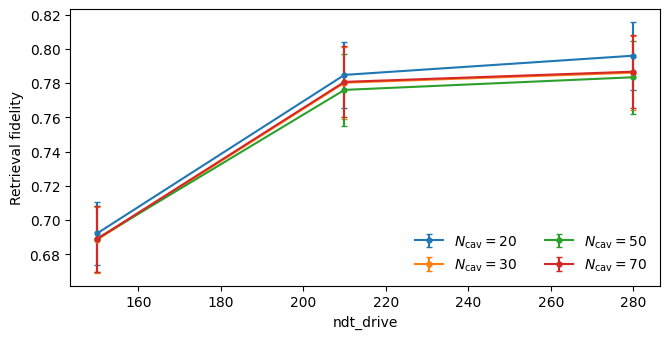

In [26]:
def annotated_heatmap(
    axis,
    values,
    title,
    colorbar_label,
    value_format,
    cmap="viridis",
):
    image = axis.imshow(values, origin="lower", aspect="auto", cmap=cmap)
    axis.set_xticks(np.arange(len(ndt_drive_values)))
    axis.set_xticklabels(ndt_drive_values)
    axis.set_yticks(np.arange(len(N_cav_values)))
    axis.set_yticklabels(N_cav_values)
    axis.set_xlabel("ndt_drive")
    axis.set_ylabel(r"$N_{\rm cav}$")
    axis.set_title(title)
    for row in range(values.shape[0]):
        for column in range(values.shape[1]):
            axis.text(
                column,
                row,
                value_format.format(values[row, column]),
                ha="center",
                va="center",
                fontsize=7,
                color=(
                    "white"
                    if values[row, column] < np.nanmedian(values)
                    else "black"
                ),
            )
    colorbar = axis.figure.colorbar(image, ax=axis)
    colorbar.set_label(colorbar_label)


fig, axes = plt.subplots(2, 2, figsize=(10.0, 7.4))
annotated_heatmap(
    axes[0, 0],
    mean_fidelity,
    "Mean retrieval fidelity",
    "Fidelity",
    "{:.4f}",
)
annotated_heatmap(
    axes[0, 1],
    1.0e3 * paired_mean_difference,
    "Paired difference from reference",
    r"$10^3\,\Delta F$",
    "{:+.2f}",
    cmap="coolwarm",
)
annotated_heatmap(
    axes[1, 0],
    np.log10(np.maximum(worst_edge_population, 1.0e-14)),
    "Worst upper-three-level population",
    r"$\log_{10}(p_{\rm edge,max})$",
    "{:.1f}",
    cmap="magma",
)
annotated_heatmap(
    axes[1, 1],
    total_seconds,
    "Compilation + evaluation time",
    "Seconds",
    "{:.0f}",
    cmap="cividis",
)
fig.tight_layout()
fig.savefig(results_folder / "convergence_heatmaps.png", dpi=180)


fig, ax = plt.subplots(figsize=(6.8, 3.5))
for N_index, N_cav_value in enumerate(N_cav_values):
    ax.errorbar(
        ndt_drive_values,
        mean_fidelity[N_index],
        yerr=fidelity_sem[N_index],
        marker="o",
        ms=3.5,
        capsize=2,
        label=fr"$N_{{\rm cav}}={N_cav_value}$",
    )
ax.set_xlabel("ndt_drive")
ax.set_ylabel("Retrieval fidelity")
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
fig.savefig(results_folder / "fidelity_convergence.png", dpi=180)


## Save the analyzed results

The final archive contains both raw paired samples and derived convergence
metrics. The JSON file records the checkpoint and all acceptance thresholds so
the comparison can be reproduced later.


In [ ]:
np.savez(
    results_folder / "convergence_analysis.npz",
    N_cav_values=N_cav_values_array,
    ndt_drive_values=ndt_drive_values_array,
    fidelity_samples=fidelity_samples,
    edge_population_samples=edge_population_samples,
    max_photon_samples=max_photon_samples,
    mean_fidelity=mean_fidelity,
    fidelity_sem=fidelity_sem,
    paired_mean_difference=paired_mean_difference,
    paired_difference_sem=paired_difference_sem,
    paired_rms_difference=paired_rms_difference,
    paired_max_abs_difference=paired_max_abs_difference,
    worst_edge_population=worst_edge_population,
    worst_mean_photon=worst_mean_photon,
    compile_first_batch_seconds=compile_first_batch_seconds,
    remaining_evaluation_seconds=remaining_evaluation_seconds,
    converged=converged,
)

metadata = {
    "selected_run_folder": str(selected_run_folder),
    "selected_checkpoint_path": str(selected_checkpoint_path),
    "num_feedback_steps_test": num_feedback_steps_test,
    "N_cav_values": N_cav_values,
    "ndt_drive_values": ndt_drive_values,
    "evaluation_seed": evaluation_seed,
    "evaluation_microbatch_size": evaluation_microbatch_size,
    "evaluation_num_microbatches": evaluation_num_microbatches,
    "mean_fidelity_tolerance": mean_fidelity_tolerance,
    "rms_fidelity_tolerance": rms_fidelity_tolerance,
    "edge_population_tolerance": edge_population_tolerance,
    "edge_fock_levels": edge_fock_levels,
    "gpu_memory_fraction": os.environ[
        "XLA_PYTHON_CLIENT_MEM_FRACTION"
    ],
}
with (results_folder / "metadata.json").open(
    "w", encoding="utf-8"
) as file:
    json.dump(metadata, file, indent=2)

print("Saved final convergence analysis to:", results_folder)


Saved final convergence analysis to: /home/user/python_experiments/train_feedback_grape/quantum_memory/20260720_0935/convergence_tests/20260721_141129


: 